<a href="https://colab.research.google.com/github/dee431/-The-Airline-Experience-Investment-Planner/blob/main/The_Airline_Experience_Investment_Planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Airline Experience Investment Planner¶
Robust, budget-constrained counterfactual service portfolios
Decision question: If an airline can improve at most two service touchpoints, which portfolio produces the largest model-estimated movement among historically dissatisfied passengers?

This notebook turns a satisfaction classifier into a constrained scenario simulator. It compares four planning rules:

Highest-SHAP-first — prioritize what the predictive model uses most.
Kano-priority-first — prioritize asymmetric penalty and reward signals.
Greedy optimization — add the largest marginal probability gain per cost unit.
Robust portfolio — maximize the lower-tail gain across bootstrap models.
Critical limitation
A counterfactual model prediction is not a causal effect. The survey contains associations from one observed journey, not randomized service interventions. The outputs below are hypotheses for experimentation and resource-planning—not promises that changing a rating will cause satisfaction to change.
Organizational multi-instance counterfactual research motivates group-level policy recommendations (Decision Support Systems, 2024). Causal-recourse research shows why actions cannot be guaranteed without knowledge of the underlying causal system (NeurIPS, 2020).

In [ ]:
from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    log_loss, accuracy_score,
)
from sklearn.calibration import calibration_curve
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
NAVY = "#0B1F33"
SKY = "#25A7D9"
TEAL = "#00A6A6"
CORAL = "#F2645A"
AMBER = "#F2B134"
PURPLE = "#7667B8"
CLOUD = "#F4F7FA"
SLATE = "#5F7183"
INK = "#172B3A"
GRID = "#DCE5EC"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "grid.color": GRID, "grid.alpha": 0.65,
    "font.family": "DejaVu Sans", "text.color": INK,
    "xtick.color": SLATE, "ytick.color": SLATE, "figure.dpi": 120,
})

def finish_axis(ax, *, xgrid=True, ygrid=False):
    if xgrid:
        ax.grid(True, axis="x", color=GRID, linewidth=0.8)
    else:
        ax.grid(False, axis="x")
    if ygrid:
        ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    else:
        ax.grid(False, axis="y")
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    return ax

def expected_calibration_error(y_true, p, bins=12):
    frame = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(p)})
    frame["bin"] = pd.cut(frame["p"], np.linspace(0, 1, bins + 1), include_lowest=True)
    grouped = frame.groupby("bin", observed=True).agg(y_rate=("y", "mean"), p_mean=("p", "mean"), n=("y", "size"))
    return ((grouped["y_rate"] - grouped["p_mean"]).abs() * grouped["n"]).sum() / len(frame)

1. Load the survey and define the prediction contract¶
The supplied Kaggle path is checked first, followed by a local fallback. Service score 0 is not treated as an improvable low score: it is converted to missing plus an explicit not_applicable indicator. This protects the simulator from recommending nonsense such as “improve Wi-Fi from N/A to 1.”

In [ ]:
KAGGLE_PATH = Path(arseniyshutko_binary_aviation_satisfaction_129k_path) / "data.csv"
LOCAL_PATH = Path.cwd() / "data.csv"
data_path = next((p for p in [KAGGLE_PATH, LOCAL_PATH] if p.exists()), None)
if data_path is None:
    discovered = sorted(Path.cwd().glob("**/data.csv"))
    data_path = discovered[0] if discovered else None
if data_path is None:
    raise FileNotFoundError("Attach the Kaggle dataset or place data.csv beside this notebook.")

raw = pd.read_csv(data_path)
if not pd.api.types.is_bool_dtype(raw["satisfaction"]):
    mapping = {"true": True, "false": False, "satisfied": True,
               "neutral or dissatisfied": False}
    raw["satisfaction"] = raw["satisfaction"].astype(str).str.strip().str.lower().map(mapping)
    assert raw["satisfaction"].notna().all(), "Unknown satisfaction label."

SERVICE_COLS = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Cleanliness",
]
CAT_COLS = ["Gender", "Customer Type", "Type of Travel", "Class"]

missing_schema = set(SERVICE_COLS + CAT_COLS + ["satisfaction"]).difference(raw.columns)
assert not missing_schema, f"Dataset schema mismatch: {sorted(missing_schema)}"

SERVICE_SHORT = {
    "Inflight wifi service": "Wi-Fi", "Departure/Arrival time convenient": "Schedule",
    "Ease of Online booking": "Online booking", "Gate location": "Gate",
    "Food and drink": "Food", "Online boarding": "Online boarding",
    "Seat comfort": "Seat", "Inflight entertainment": "Entertainment",
    "On-board service": "On-board", "Leg room service": "Leg room",
    "Baggage handling": "Baggage", "Checkin service": "Check-in",
    "Cleanliness": "Cleanliness",
}

y = raw["satisfaction"].astype(int)
X = raw.drop(columns="satisfaction").copy()
for col in CAT_COLS:
    X[col] = X[col].astype("category")
for col in SERVICE_COLS:
    X[f"{col}__not_applicable"] = X[col].eq(0).astype("int8")
    X[col] = X[col].mask(X[col].eq(0)).astype(float)

print(f"Loaded {len(raw):,} passenger records from {data_path}")
print(f"Model matrix: {X.shape[1]} features, including {len(SERVICE_COLS)} service ratings and N/A flags")

Loaded 129,880 passenger records from /kaggle/input/binary-aviation-satisfaction-129k/data.csv
Model matrix: 34 features, including 13 service ratings and N/A flags


Four independent data roles¶

Split	Purpose	Share
Model training	Learn satisfaction relationships	60%
Calibration	Early stopping and isotonic probability calibration	15%
Portfolio design	Choose actions and budgets	10%
Final test	Evaluate chosen policies once	15%
The untouched final test set prevents a portfolio from looking effective merely because it was selected on the same passengers used for reporting.

In [ ]:
all_idx = np.arange(len(raw))
train_idx, remainder_idx = train_test_split(
    all_idx, test_size=0.40, stratify=y, random_state=SEED
)
cal_idx, remainder_idx = train_test_split(
    remainder_idx, test_size=0.625, stratify=y.iloc[remainder_idx], random_state=SEED
)
policy_idx, test_idx = train_test_split(
    remainder_idx, test_size=0.60, stratify=y.iloc[remainder_idx], random_state=SEED
)

split_manifest = pd.DataFrame({
    "role": ["Model training", "Calibration", "Portfolio design", "Final test"],
    "rows": [len(train_idx), len(cal_idx), len(policy_idx), len(test_idx)],
    "satisfaction_rate": [y.iloc[i].mean() for i in [train_idx, cal_idx, policy_idx, test_idx]],
})
split_manifest["share"] = split_manifest["rows"] / len(raw)
display(split_manifest.style.format({"share": "{:.1%}", "satisfaction_rate": "{:.2%}"}))

,role,rows,satisfaction_rate,share
0,Model training,77928,43.45%,60.0%
1,Calibration,19482,43.45%,15.0%
2,Portfolio design,12988,43.45%,10.0%
3,Final test,19482,43.45%,15.0%


**2. Train and calibrate the predictive engine¶**
LightGBM is used because the optimization engine will score thousands of modified passenger portfolios. Isotonic regression calibrates its probabilities. Discrimination tells us whether the model ranks passengers; calibration tells us whether a predicted movement from 0.25 to 0.35 is numerically meaningful enough for scenario comparison.

In [ ]:
model_params = dict(
    objective="binary", n_estimators=900, learning_rate=0.04,
    num_leaves=31, min_child_samples=80, subsample=0.85,
    subsample_freq=1, colsample_bytree=0.85, reg_lambda=2.0,
    verbosity=-1, n_jobs=-1,
)

main_model = LGBMClassifier(**model_params, random_state=SEED)
main_model.fit(
    X.iloc[train_idx], y.iloc[train_idx],
    categorical_feature=CAT_COLS,
    eval_set=[(X.iloc[cal_idx], y.iloc[cal_idx])],
    eval_metric="binary_logloss",
    callbacks=[early_stopping(70, verbose=False)],
)

cal_raw = main_model.predict_proba(X.iloc[cal_idx])[:, 1]
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(cal_raw, y.iloc[cal_idx])

def calibrated_predict(model, iso, frame):
    return iso.predict(model.predict_proba(frame)[:, 1])

test_raw_p = main_model.predict_proba(X.iloc[test_idx])[:, 1]
test_cal_p = calibrator.predict(test_raw_p)

def metric_row(name, p):
    yt = y.iloc[test_idx]
    clipped = np.clip(p, 1e-6, 1 - 1e-6)
    return {
        "probabilities": name,
        "ROC-AUC": roc_auc_score(yt, p),
        "PR-AUC": average_precision_score(yt, p),
        "Brier": brier_score_loss(yt, p),
        "Log loss": log_loss(yt, clipped),
        "ECE": expected_calibration_error(yt, p),
        "Accuracy @ 0.5": accuracy_score(yt, p >= 0.5),
    }

model_metrics = pd.DataFrame([
    metric_row("Raw LightGBM", test_raw_p),
    metric_row("Isotonic calibrated", test_cal_p),
])
display(model_metrics.style.format({c: "{:.4f}" for c in model_metrics.columns if c != "probabilities"}))
print(f"Best boosting iteration: {main_model.best_iteration_}")

,probabilities,ROC-AUC,PR-AUC,Brier,Log loss,ECE,Accuracy @ 0.5
0,Raw LightGBM,0.9950,0.9941,0.0268,0.0864,0.0039,0.9628
1,Isotonic calibrated,0.9949,0.9930,0.0268,0.0867,0.0024,0.9625


Best boosting iteration: 860


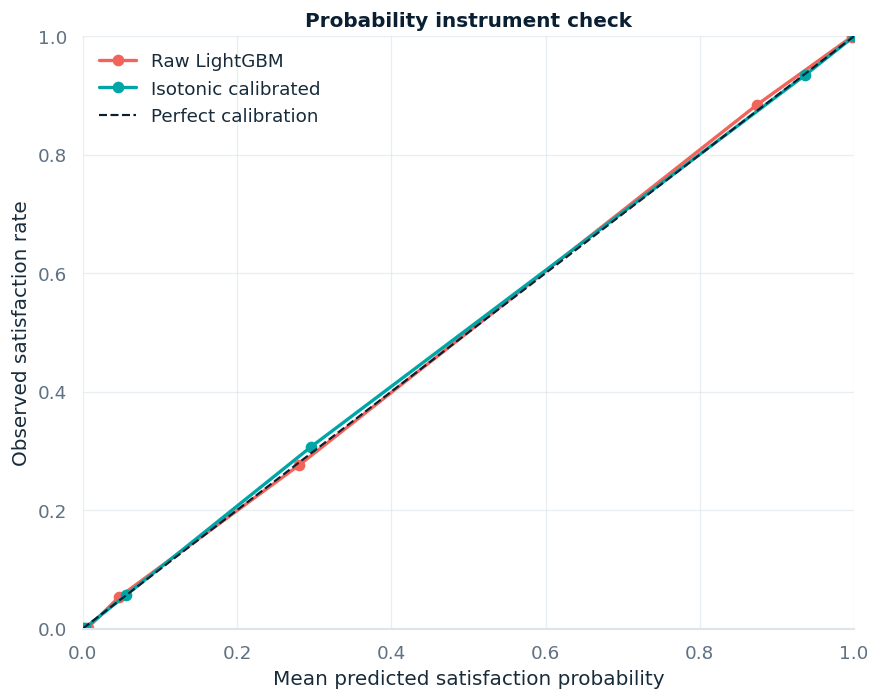

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for label, probs, color in [
    ("Raw LightGBM", test_raw_p, CORAL),
    ("Isotonic calibrated", test_cal_p, TEAL),
]:
    observed, predicted = calibration_curve(y.iloc[test_idx], probs, n_bins=12, strategy="quantile")
    ax.plot(predicted, observed, marker="o", lw=2, color=color, label=label)
ax.plot([0, 1], [0, 1], ls="--", color=NAVY, lw=1.3, label="Perfect calibration")
ax.set(xlabel="Mean predicted satisfaction probability", ylabel="Observed satisfaction rate",
       title="Probability instrument check")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
finish_axis(ax, xgrid=True, ygrid=True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**3. Define actions, dependencies, and hypothetical costs¶**
An action raises a selected rating by one point (1→2, …, 4→5) for every eligible passenger in the selected planning cohort.

Rules:

Ratings already at 5 cannot improve.
N/A (0 in the raw file) cannot improve.
At most two touchpoints may be selected.
Cabin environment attributes—seat, cleanliness, food, entertainment—cannot appear alone. Selecting from this linked system requires a two-touchpoint cabin portfolio.
Costs are scenario assumptions, not observed accounting data.

In [ ]:
CABIN_LINKED = {
    "Seat comfort", "Cleanliness", "Food and drink", "Inflight entertainment"
}
SERVICE_ORDER = {name: i for i, name in enumerate(SERVICE_COLS)}

def canonical(portfolio):
    return tuple(sorted(portfolio, key=SERVICE_ORDER.get))

def valid_final_portfolio(portfolio):
    portfolio = set(portfolio)
    cabin_count = len(portfolio & CABIN_LINKED)
    return 1 <= len(portfolio) <= 2 and cabin_count != 1

ALL_ACTION_SETS = [
    canonical(p)
    for size in (1, 2)
    for p in itertools.combinations(SERVICE_COLS, size)
]
VALID_PORTFOLIOS = [p for p in ALL_ACTION_SETS if valid_final_portfolio(p)]

COST_SCENARIOS = {
    "Equal units": {
        "budget": 2.0,
        "costs": {s: 1.0 for s in SERVICE_COLS},
    },
    "Digital-first": {
        "budget": 2.2,
        "costs": {
            "Inflight wifi service": 1.2, "Departure/Arrival time convenient": 1.6,
            "Ease of Online booking": 0.5, "Gate location": 1.7,
            "Food and drink": 1.4, "Online boarding": 0.5,
            "Seat comfort": 2.2, "Inflight entertainment": 1.5,
            "On-board service": 1.3, "Leg room service": 2.6,
            "Baggage handling": 1.6, "Checkin service": 0.8,
            "Cleanliness": 1.4,
        },
    },
    "Operations constrained": {
        "budget": 3.0,
        "costs": {
            "Inflight wifi service": 2.4, "Departure/Arrival time convenient": 2.0,
            "Ease of Online booking": 0.6, "Gate location": 2.5,
            "Food and drink": 1.5, "Online boarding": 0.6,
            "Seat comfort": 2.7, "Inflight entertainment": 2.2,
            "On-board service": 1.6, "Leg room service": 3.2,
            "Baggage handling": 2.4, "Checkin service": 1.0,
            "Cleanliness": 1.8,
        },
    },
}

def portfolio_cost(portfolio, scenario):
    costs = COST_SCENARIOS[scenario]["costs"]
    return sum(costs[s] for s in portfolio)

def portfolio_label(portfolio):
    return " + ".join(SERVICE_SHORT[s] for s in portfolio)

cost_table = pd.DataFrame({
    scenario: pd.Series(spec["costs"]) for scenario, spec in COST_SCENARIOS.items()
}).rename(index=SERVICE_SHORT)
display(cost_table.style.format("{:.1f}").set_caption("Hypothetical cost units by scenario"))
print(f"Candidate action sets: {len(ALL_ACTION_SETS)}; valid final portfolios after dependency rules: {len(VALID_PORTFOLIOS)}")

,Equal units,Digital-first,Operations constrained
Wi-Fi,1.0,1.2,2.4
Schedule,1.0,1.6,2.0
Online booking,1.0,0.5,0.6
Gate,1.0,1.7,2.5
Food,1.0,1.4,1.5
Online boarding,1.0,0.5,0.6
Seat,1.0,2.2,2.7
Entertainment,1.0,1.5,2.2
On-board,1.0,1.3,1.6
Leg room,1.0,2.6,3.2


Candidate action sets: 91; valid final portfolios after dependency rules: 51


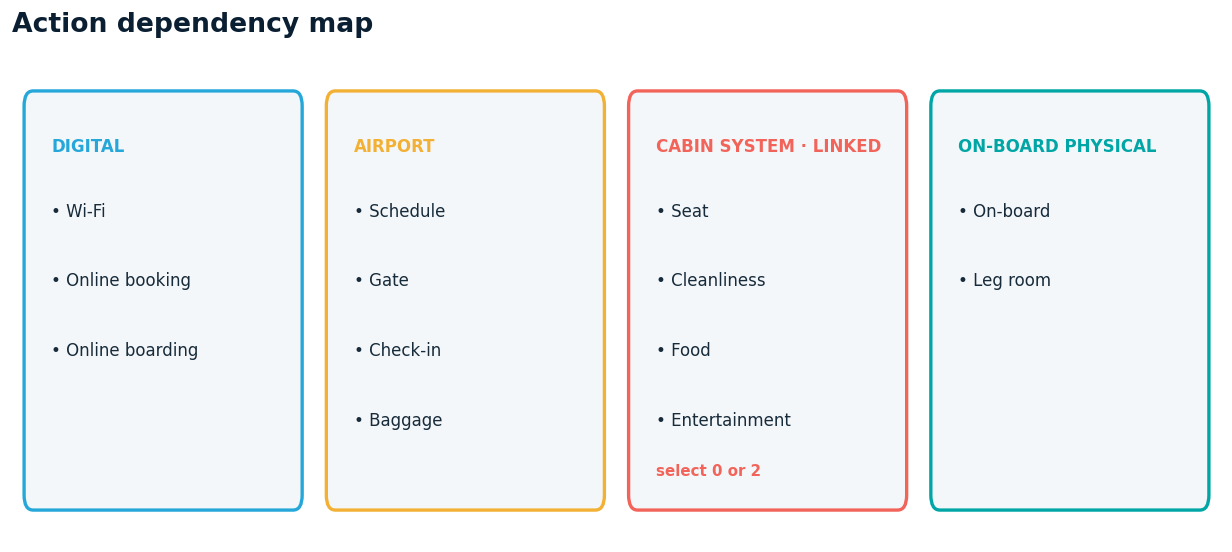

In [ ]:
# Visualize the action system rather than hiding dependencies in optimizer code.
groups = {
    "Digital": ["Inflight wifi service", "Ease of Online booking", "Online boarding"],
    "Airport": ["Departure/Arrival time convenient", "Gate location", "Checkin service", "Baggage handling"],
    "Cabin system · linked": ["Seat comfort", "Cleanliness", "Food and drink", "Inflight entertainment"],
    "On-board physical": ["On-board service", "Leg room service"],
}
group_colors = [SKY, AMBER, CORAL, TEAL]
fig, ax = plt.subplots(figsize=(13, 5.4))
ax.set_xlim(0, 4); ax.set_ylim(0, 1); ax.axis("off")
for i, ((group, services), color) in enumerate(zip(groups.items(), group_colors)):
    x = i + 0.06
    box = FancyBboxPatch((x, 0.08), 0.88, 0.80, boxstyle="round,pad=0.02,rounding_size=0.03",
                         facecolor=CLOUD, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + 0.07, 0.78, group.upper(), color=color, fontsize=10, weight="bold")
    for j, service in enumerate(services):
        ax.text(x + 0.07, 0.65 - j * 0.14, "• " + SERVICE_SHORT[service], fontsize=10, color=INK)
    if "linked" in group:
        ax.text(x + 0.07, 0.13, "select 0 or 2", fontsize=9, color=CORAL, weight="bold")
ax.set_title("Action dependency map", loc="left", fontsize=16)
plt.show()

**4. Build a bootstrap model council¶**
The robust planner should not depend on one fitted model. Six bootstrap LightGBM models are added to the main model. Every member receives its own isotonic calibrator. The robust objective is the 10th percentile of model-estimated mean uplift, which penalizes portfolios whose value disappears under plausible refits.

In [ ]:
rng = np.random.default_rng(SEED)
MODEL_COUNCIL = [("main", main_model, calibrator)]
bootstrap_rows = []

bootstrap_params = model_params.copy()
bootstrap_params["n_estimators"] = int(main_model.best_iteration_ or 700)

for b in range(6):
    sample_idx = rng.choice(train_idx, size=len(train_idx), replace=True)
    model = LGBMClassifier(**bootstrap_params, random_state=SEED + 100 + b)
    model.fit(X.iloc[sample_idx], y.iloc[sample_idx], categorical_feature=CAT_COLS)
    raw_cal = model.predict_proba(X.iloc[cal_idx])[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip").fit(raw_cal, y.iloc[cal_idx])
    test_p = calibrated_predict(model, iso, X.iloc[test_idx])
    MODEL_COUNCIL.append((f"bootstrap_{b+1}", model, iso))
    bootstrap_rows.append({
        "model": f"bootstrap_{b+1}",
        "ROC-AUC": roc_auc_score(y.iloc[test_idx], test_p),
        "Brier": brier_score_loss(y.iloc[test_idx], test_p),
    })

bootstrap_metrics = pd.DataFrame(bootstrap_rows)
display(bootstrap_metrics.style.format({"ROC-AUC": "{:.4f}", "Brier": "{:.4f}"}))
print(f"Model council size: {len(MODEL_COUNCIL)}")

,model,ROC-AUC,Brier
0,bootstrap_1,0.9946,0.0278
1,bootstrap_2,0.9944,0.0278
2,bootstrap_3,0.9944,0.0281
3,bootstrap_4,0.9945,0.0277
4,bootstrap_5,0.9945,0.0281
5,bootstrap_6,0.9944,0.0282


Model council size: 7


**5. Construct planning cohorts and simulate every action set¶**
Policies are designed and evaluated only among respondents whose observed outcome is dissatisfied. This makes the target population explicit. It does not imply the airline would know future dissatisfaction in real time; the notebook is a post-survey planning analysis.

Intersectional cohorts with insufficient dissatisfied records in either the design or final-test split are excluded from segment optimization.

In [ ]:
def segment_labels(frame):
    return (
        frame["Customer Type"].astype(str).str.replace(" Customer", "", regex=False)
        + " · " + frame["Type of Travel"].astype(str).str.replace(" travel", "", case=False, regex=False)
        + " · " + frame["Class"].astype(str)
    )

policy_negative_idx = policy_idx[y.iloc[policy_idx].to_numpy() == 0]
test_negative_idx = test_idx[y.iloc[test_idx].to_numpy() == 0]

raw_policy_neg = raw.iloc[policy_negative_idx].copy()
raw_test_neg = raw.iloc[test_negative_idx].copy()
raw_policy_neg["segment"] = segment_labels(raw_policy_neg)
raw_test_neg["segment"] = segment_labels(raw_test_neg)

policy_counts = raw_policy_neg["segment"].value_counts()
test_counts = raw_test_neg["segment"].value_counts()
valid_segments = sorted([
    s for s in set(policy_counts.index) & set(test_counts.index)
    if policy_counts[s] >= 75 and test_counts[s] >= 100
])
SEGMENTS = ["Network-wide"] + valid_segments

segment_manifest = pd.DataFrame({
    "segment": valid_segments,
    "design_dissatisfied": [policy_counts[s] for s in valid_segments],
    "test_dissatisfied": [test_counts[s] for s in valid_segments],
})
display(segment_manifest)
print(f"Planning population: {len(raw_policy_neg):,} design + {len(raw_test_neg):,} final-test dissatisfied records")

,segment,design_dissatisfied,test_dissatisfied
0,Loyal · Business · Business,1119,1634
1,Loyal · Business · Eco,608,946
2,Loyal · Business · Eco Plus,196,331
3,Loyal · Personal · Business,243,344
4,Loyal · Personal · Eco,2973,4400
5,Loyal · Personal · Eco Plus,408,608
6,disloyal · Business · Business,535,862
7,disloyal · Business · Eco,1159,1749
8,disloyal · Business · Eco Plus,87,113


Planning population: 7,345 design + 11,018 final-test dissatisfied records


**6. Compute SHAP and Kano planning signals¶**
LightGBM's contribution output implements TreeSHAP values on the model's raw score. The Kano-style signal separates the dissatisfaction penalty (1–2 versus 3) from the delight reward (4–5 versus 3) and weights their positive components by the share eligible to improve.

In [ ]:
# SHAP signals are derived only from the independent portfolio-design population.
policy_contrib = main_model.booster_.predict(X.loc[policy_negative_idx], pred_contrib=True)
contrib_frame = pd.DataFrame(
    np.abs(policy_contrib[:, :-1]), index=policy_negative_idx, columns=X.columns
)
contrib_frame["segment"] = raw_policy_neg["segment"]

shap_rows = []
for segment in SEGMENTS:
    part = contrib_frame if segment == "Network-wide" else contrib_frame[contrib_frame["segment"].eq(segment)]
    means = part[SERVICE_COLS].mean()
    for service, value in means.items():
        shap_rows.append({"segment": segment, "service": service, "shap_signal": value})
shap_signal = pd.DataFrame(shap_rows)

train_raw = raw.iloc[train_idx].copy()
train_raw["segment"] = segment_labels(train_raw)
kano_rows = []
for segment in SEGMENTS:
    part = train_raw if segment == "Network-wide" else train_raw[train_raw["segment"].eq(segment)]
    for service in SERVICE_COLS:
        valid = part[part[service].between(1, 5)]
        low = valid.loc[valid[service].between(1, 2), "satisfaction"].mean()
        mid = valid.loc[valid[service].eq(3), "satisfaction"].mean()
        high = valid.loc[valid[service].between(4, 5), "satisfaction"].mean()
        penalty = max(float(mid - low), 0) if pd.notna(mid) and pd.notna(low) else 0
        reward = max(float(high - mid), 0) if pd.notna(high) and pd.notna(mid) else 0
        eligible_share = part[service].between(1, 4).mean()
        kano_rows.append({
            "segment": segment, "service": service,
            "penalty": penalty, "reward": reward,
            "kano_signal": (penalty + reward) * eligible_share,
        })
kano_signal = pd.DataFrame(kano_rows)

signal_preview = (
    shap_signal.query("segment == 'Network-wide'")
    .merge(kano_signal.query("segment == 'Network-wide'"), on=["segment", "service"])
    .sort_values("kano_signal", ascending=False)
)
signal_preview["service"] = signal_preview["service"].map(SERVICE_SHORT)
display(signal_preview[["service", "shap_signal", "penalty", "reward", "kano_signal"]]
        .style.format({c: "{:.3f}" for c in ["shap_signal", "penalty", "reward", "kano_signal"]}))

,service,shap_signal,penalty,reward,kano_signal
5,Online boarding,1.161,0.015,0.583,0.465
0,Wi-Fi,1.804,0.000,0.491,0.422
7,Entertainment,0.232,0.097,0.351,0.338
6,Seat,0.254,0.000,0.384,0.286
12,Cleanliness,0.159,0.226,0.137,0.284
8,On-board,0.192,0.092,0.262,0.273
9,Leg room,0.182,0.025,0.325,0.264
2,Online booking,0.122,0.000,0.309,0.254
11,Check-in,0.309,0.206,0.072,0.222
10,Baggage,0.393,0.000,0.301,0.222


**7. Select four policies without touching the final test set¶**
Every method obeys the same cost, cardinality, N/A, and cabin-linkage rules. The robust method searches all valid portfolios and maximizes the 10th-percentile uplift across the seven-model council.

In [ ]:
design_main = design_sim[design_sim["model"].eq("main")].copy()
design_robust = (
    design_sim.groupby(["segment", "portfolio"], as_index=False)["mean_delta"]
    .agg(uplift_mean="mean", uplift_p10=lambda s: s.quantile(0.10), uplift_std="std")
)

def feasible_portfolios(scenario):
    budget = COST_SCENARIOS[scenario]["budget"]
    return [p for p in VALID_PORTFOLIOS if portfolio_cost(p, scenario) <= budget + 1e-9]

def signal_choice(segment, scenario, signal_df, signal_col):
    scores = signal_df[signal_df["segment"].eq(segment)].set_index("service")[signal_col]
    candidates = feasible_portfolios(scenario)
    return max(candidates, key=lambda p: (sum(scores.get(s, 0) for s in p), -portfolio_cost(p, scenario)))

def greedy_choice(segment, scenario):
    lookup = design_main[design_main["segment"].eq(segment)].set_index("portfolio")["mean_delta"].to_dict()
    costs = COST_SCENARIOS[scenario]["costs"]
    budget = COST_SCENARIOS[scenario]["budget"]
    selected = tuple()
    current_gain = 0.0
    for step in range(2):
        options = []
        for service in SERVICE_COLS:
            if service in selected:
                continue
            candidate = canonical(selected + (service,))
            if portfolio_cost(candidate, scenario) > budget + 1e-9:
                continue
            if step == 0:
                can_finish = valid_final_portfolio(candidate) or any(
                    valid_final_portfolio(canonical(candidate + (other,)))
                    and portfolio_cost(canonical(candidate + (other,)), scenario) <= budget + 1e-9
                    for other in SERVICE_COLS if other not in candidate
                )
                if not can_finish:
                    continue
            elif not valid_final_portfolio(candidate):
                continue
            gain = lookup.get(candidate, -np.inf)
            marginal_per_cost = (gain - current_gain) / costs[service]
            options.append((marginal_per_cost, gain, service, candidate))
        if not options:
            break
        _, current_gain, _, selected = max(options)
    if not valid_final_portfolio(selected):
        valid = feasible_portfolios(scenario)
        selected = max(valid, key=lambda p: lookup.get(p, -np.inf) / portfolio_cost(p, scenario))
    return selected

def robust_choice(segment, scenario):
    candidates = feasible_portfolios(scenario)
    part = design_robust[
        design_robust["segment"].eq(segment) & design_robust["portfolio"].isin(candidates)
    ]
    return part.sort_values(["uplift_p10", "uplift_mean"], ascending=False).iloc[0]["portfolio"]

choice_rows = []
for scenario in COST_SCENARIOS:
    for segment in SEGMENTS:
        choices = {
            "Highest-SHAP-first": signal_choice(segment, scenario, shap_signal, "shap_signal"),
            "Kano-priority-first": signal_choice(segment, scenario, kano_signal, "kano_signal"),
            "Greedy optimization": greedy_choice(segment, scenario),
            "Robust portfolio": robust_choice(segment, scenario),
        }
        for method, portfolio in choices.items():
            choice_rows.append({
                "scenario": scenario, "segment": segment, "method": method,
                "portfolio": portfolio, "portfolio_label": portfolio_label(portfolio),
                "cost": portfolio_cost(portfolio, scenario),
            })

policy_choices = pd.DataFrame(choice_rows)
network_choices = policy_choices[policy_choices["segment"].eq("Network-wide")]
display(network_choices[["scenario", "method", "portfolio_label", "cost"]]
        .style.format({"cost": "{:.1f}"}).set_caption("Policies selected before final testing"))

,scenario,method,portfolio_label,cost
0,Equal units,Highest-SHAP-first,Wi-Fi + Online boarding,2.0
1,Equal units,Kano-priority-first,Wi-Fi + Online boarding,2.0
2,Equal units,Greedy optimization,Wi-Fi + Check-in,2.0
3,Equal units,Robust portfolio,Wi-Fi + Check-in,2.0
40,Digital-first,Highest-SHAP-first,Wi-Fi + Online boarding,1.7
41,Digital-first,Kano-priority-first,Wi-Fi + Online boarding,1.7
42,Digital-first,Greedy optimization,Wi-Fi + Online boarding,1.7
43,Digital-first,Robust portfolio,Wi-Fi + Check-in,2.0
80,Operations constrained,Highest-SHAP-first,Wi-Fi + Online boarding,3.0
81,Operations constrained,Kano-priority-first,Wi-Fi + Online boarding,3.0


**8. Final-test comparison¶**
Mean Δp is the average movement in calibrated predicted satisfaction probability. Helped ≥5pp is the share receiving at least a five-percentage-point modeled gain. Flip rate is the share moving from below to above the 0.5 prediction threshold. None is a measured treatment effect.

In [ ]:
def apply_portfolio(X_frame, raw_frame, portfolio):
    modified = X_frame.copy()
    eligible_any = pd.Series(False, index=raw_frame.index)
    for service in portfolio:
        eligible = raw_frame[service].between(1, 4)
        eligible_any |= eligible
        modified.loc[eligible, service] = raw_frame.loc[eligible, service].astype(float) + 1.0
    return modified, eligible_any.to_numpy()

def segment_masks(raw_frame):
    labels = raw_frame["segment"].to_numpy()
    masks = {"Network-wide": np.ones(len(raw_frame), dtype=bool)}
    masks.update({segment: labels == segment for segment in valid_segments})
    return masks

def simulate(frame_idx, raw_frame, models, include_distribution_metrics=False):
    X_target = X.loc[frame_idx]
    masks = segment_masks(raw_frame)
    baselines = {
        model_name: calibrated_predict(model, iso, X_target)
        for model_name, model, iso in models
    }
    records = []
    for portfolio in ALL_ACTION_SETS:
        modified, eligible = apply_portfolio(X_target, raw_frame, portfolio)
        for model_name, model, iso in models:
            changed = calibrated_predict(model, iso, modified)
            base = baselines[model_name]
            delta = changed - base
            for segment, mask in masks.items():
                row = {
                    "model": model_name, "segment": segment,
                    "portfolio": portfolio, "mean_delta": delta[mask].mean(),
                }
                if include_distribution_metrics and model_name == "main":
                    row.update({
                        "median_delta": np.median(delta[mask]),
                        "helped_5pp": (delta[mask] >= 0.05).mean(),
                        "flip_rate": ((base[mask] < 0.5) & (changed[mask] >= 0.5)).mean(),
                        "eligible_share": eligible[mask].mean(),
                    })
                records.append(row)
    return pd.DataFrame(records)

# Re-generate simulation results
test_sim = simulate(test_negative_idx, raw_test_neg, [MODEL_COUNCIL[0]], include_distribution_metrics=True)

test_lookup = test_sim[test_sim["model"].eq("main")].copy()
evaluation = policy_choices.merge(
    test_lookup.drop(columns="model"), on=["segment", "portfolio"], how="left"
).merge(
    design_robust, on=["segment", "portfolio"], how="left"
)

balanced_eval = evaluation[
    evaluation["scenario"].eq("Equal units") & evaluation["segment"].eq("Network-wide")
].sort_values("mean_delta", ascending=False)

display(balanced_eval[[
    "method", "portfolio_label", "cost", "mean_delta", "helped_5pp",
    "flip_rate", "eligible_share", "uplift_p10", "uplift_std"
]].style.format({
    "cost": "{:.1f}", "mean_delta": "{:+.2%}", "helped_5pp": "{:.1%}",
    "flip_rate": "{:.1%}", "eligible_share": "{:.1%}",
    "uplift_p10": "{:+.2%}", "uplift_std": "{:.2%}",
}).set_caption("Untouched final-test results · network-wide · equal-unit budget"))

,method,portfolio_label,cost,mean_delta,helped_5pp,flip_rate,eligible_share,uplift_p10,uplift_std
3,Robust portfolio,Wi-Fi + Check-in,2.0,+21.48%,48.5%,19.1%,100.0%,+21.63%,0.27%
2,Greedy optimization,Wi-Fi + Check-in,2.0,+21.48%,48.5%,19.1%,100.0%,+21.63%,0.27%
1,Kano-priority-first,Wi-Fi + Online boarding,2.0,+20.47%,46.5%,18.3%,100.0%,+20.60%,0.29%
0,Highest-SHAP-first,Wi-Fi + Online boarding,2.0,+20.47%,46.5%,18.3%,100.0%,+20.60%,0.29%


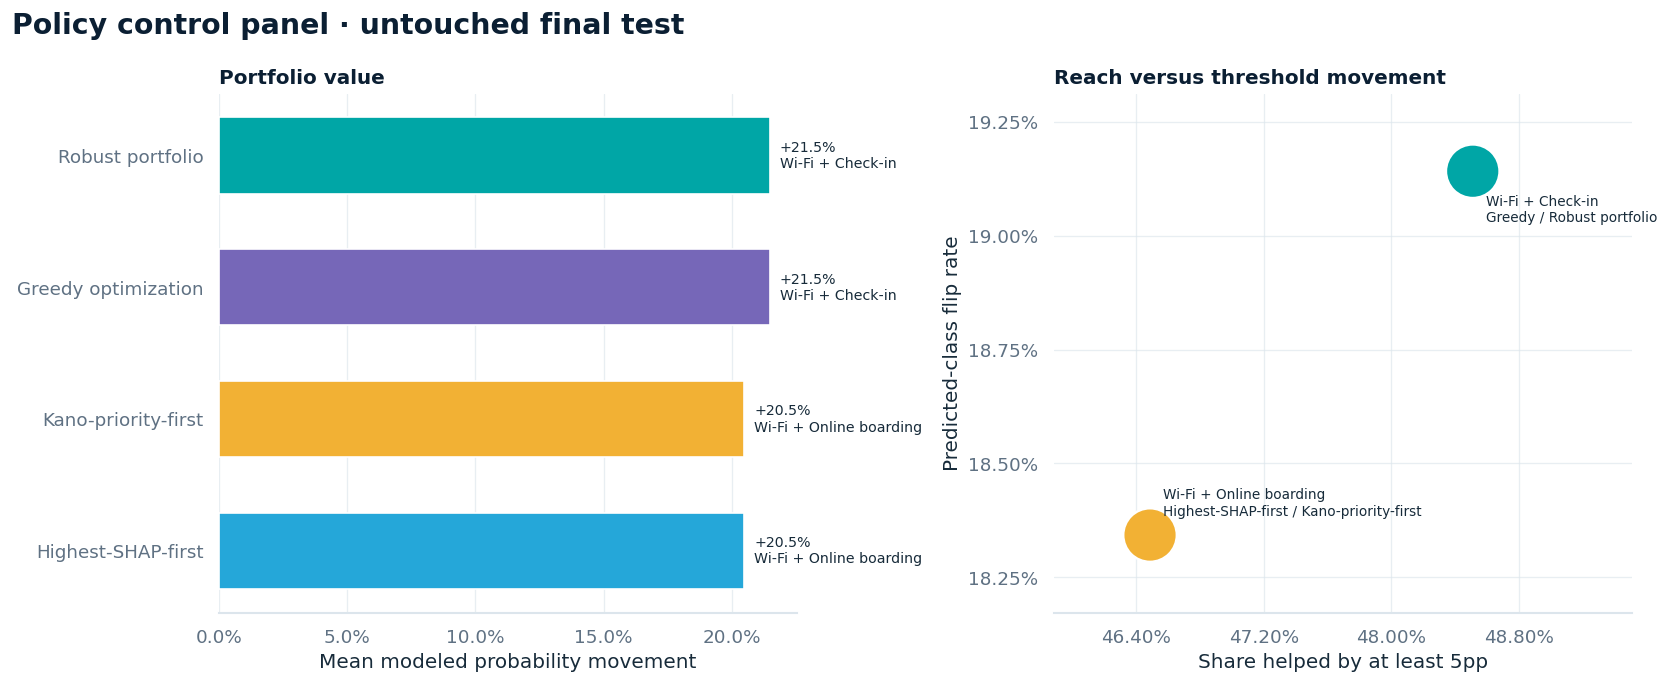

In [ ]:
method_colors = {
    "Highest-SHAP-first": SKY, "Kano-priority-first": AMBER,
    "Greedy optimization": PURPLE, "Robust portfolio": TEAL,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
plot_data = balanced_eval.sort_values("mean_delta")
ypos = np.arange(len(plot_data))
colors = plot_data["method"].map(method_colors)
axes[0].barh(ypos, plot_data["mean_delta"], color=colors, height=0.58)
for i, row in enumerate(plot_data.itertuples()):
    axes[0].text(row.mean_delta + 0.004, i, f"{row.mean_delta:+.1%}\n{row.portfolio_label}", va="center", fontsize=8.5)
axes[0].set_yticks(ypos, plot_data["method"])
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_xlabel("Mean modeled probability movement")
axes[0].set_title("Portfolio value", loc="left")
finish_axis(axes[0])

unique_plans = (
    plot_data.groupby("portfolio_label", as_index=False)
    .agg(helped_5pp=("helped_5pp", "first"), flip_rate=("flip_rate", "first"),
         eligible_share=("eligible_share", "first"),
         methods=("method", lambda s: " / ".join(x.replace(" optimization", "") for x in s)))
)
unique_plans = unique_plans.sort_values("flip_rate").reset_index(drop=True)
plan_colors = [TEAL if "Robust" in methods else AMBER for methods in unique_plans["methods"]]
axes[1].scatter(unique_plans["helped_5pp"], unique_plans["flip_rate"],
                s=180 + 850 * unique_plans["eligible_share"], c=plan_colors,
                edgecolor="white", linewidth=1.4)
for i, row in enumerate(unique_plans.itertuples()):
    axes[1].annotate(f"{row.portfolio_label}\n{row.methods}",
                     (row.helped_5pp, row.flip_rate), xytext=(8, 12 if i == 0 else -30),
                     textcoords="offset points", fontsize=8.2)
axes[1].set_xlim(unique_plans["helped_5pp"].min() - 0.006, unique_plans["helped_5pp"].max() + 0.010)
axes[1].set_ylim(unique_plans["flip_rate"].min() - 0.0017, unique_plans["flip_rate"].max() + 0.0017)
axes[1].xaxis.set_major_locator(mtick.MaxNLocator(5))
axes[1].yaxis.set_major_locator(mtick.MaxNLocator(5))
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_xlabel("Share helped by at least 5pp")
axes[1].set_ylabel("Predicted-class flip rate")
axes[1].set_title("Reach versus threshold movement", loc="left")
finish_axis(axes[1], xgrid=True, ygrid=True)

fig.suptitle("Policy control panel · untouched final test", x=0.01, ha="left", fontsize=17, color=NAVY, weight="bold")
fig.tight_layout()
plt.show()

**Cost–value frontier¶**

The frontier shows all valid network-wide portfolios under the “operations constrained” cost assumptions. A portfolio is dominated when another costs no more and produces at least as much robust lower-tail uplift.

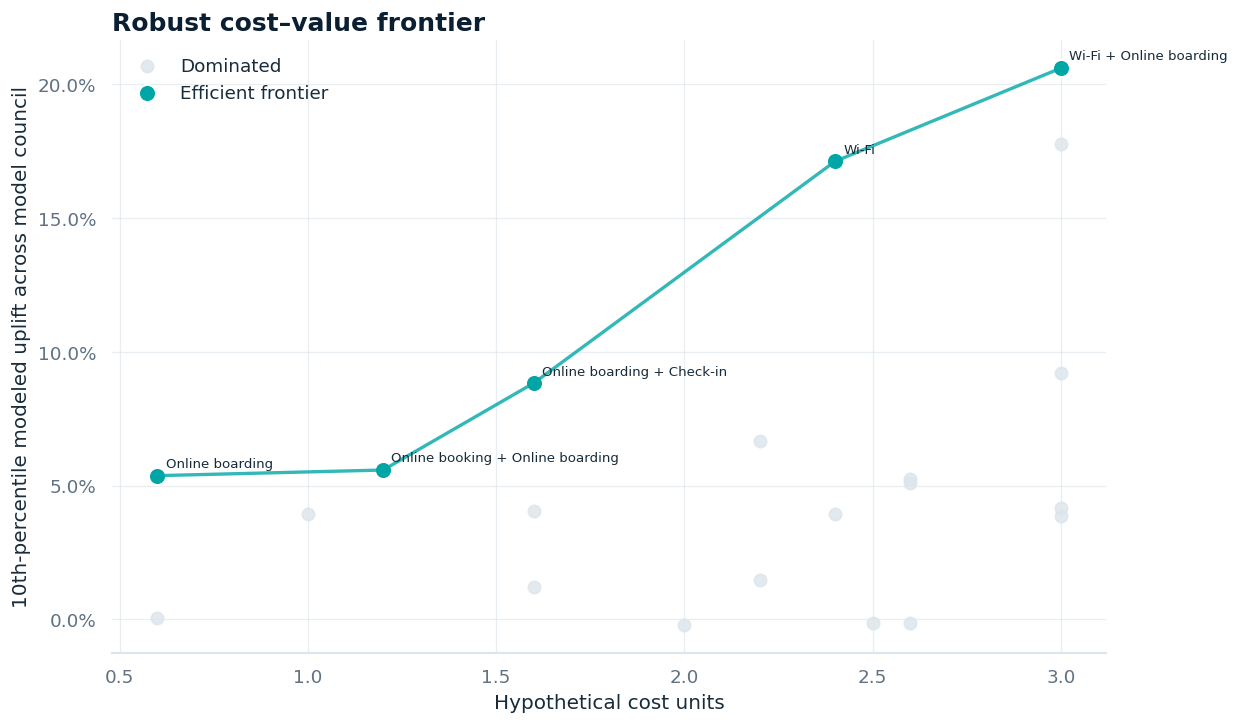

In [ ]:
frontier_scenario = "Operations constrained"
frontier = design_robust[
    (design_robust["segment"].eq("Network-wide"))
    & design_robust["portfolio"].isin(feasible_portfolios(frontier_scenario))
].copy()
frontier["cost"] = frontier["portfolio"].map(lambda p: portfolio_cost(p, frontier_scenario))
frontier["label"] = frontier["portfolio"].map(portfolio_label)
frontier = frontier.sort_values(["cost", "uplift_p10"], ascending=[True, False])
best_so_far = -np.inf
is_frontier = []
for value in frontier["uplift_p10"]:
    is_frontier.append(value > best_so_far + 1e-12)
    best_so_far = max(best_so_far, value)
frontier["efficient"] = is_frontier

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.scatter(frontier["cost"], frontier["uplift_p10"], s=55, color=GRID, alpha=0.8, label="Dominated")
efficient = frontier[frontier["efficient"]]
ax.plot(efficient["cost"], efficient["uplift_p10"], color=TEAL, lw=2, alpha=0.8)
ax.scatter(efficient["cost"], efficient["uplift_p10"], s=105, color=TEAL,
           edgecolor="white", linewidth=1.2, label="Efficient frontier")
for row in efficient.itertuples():
    ax.annotate(row.label, (row.cost, row.uplift_p10), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xlabel("Hypothetical cost units")
ax.set_ylabel("10th-percentile modeled uplift across model council")
ax.set_title("Robust cost–value frontier", loc="left", fontsize=15)
finish_axis(ax, xgrid=True, ygrid=True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**9. Segment-specific robust portfolios**
The optimizer is now allowed to choose different portfolios for different passenger systems. This tests whether a single network-wide strategy hides heterogeneous priorities.

In [ ]:
segment_robust = evaluation[
    evaluation["scenario"].eq("Equal units")
    & evaluation["method"].eq("Robust portfolio")
    & ~evaluation["segment"].eq("Network-wide")
].sort_values("mean_delta", ascending=False)

display(segment_robust[[
    "segment", "portfolio_label", "mean_delta", "helped_5pp",
    "flip_rate", "uplift_p10", "uplift_std"
]].style.format({
    "mean_delta": "{:+.2%}", "helped_5pp": "{:.1%}", "flip_rate": "{:.1%}",
    "uplift_p10": "{:+.2%}", "uplift_std": "{:.2%}",
}).set_caption("Segment-specific robust plans · independent final-test evaluation"))

,segment,portfolio_label,mean_delta,helped_5pp,flip_rate,uplift_p10,uplift_std
15,Loyal · Business · Eco Plus,Wi-Fi + Baggage,+35.19%,67.7%,35.6%,+36.84%,0.70%
11,Loyal · Business · Eco,Wi-Fi + Check-in,+34.50%,69.3%,33.5%,+34.23%,0.59%
7,Loyal · Business · Business,Online boarding + Check-in,+30.60%,53.4%,33.4%,+31.74%,1.34%
31,disloyal · Business · Business,Wi-Fi + Baggage,+21.34%,51.5%,22.5%,+19.48%,0.83%
35,disloyal · Business · Eco,Wi-Fi + Baggage,+19.18%,41.7%,18.0%,+18.63%,0.39%
39,disloyal · Business · Eco Plus,Wi-Fi + Baggage,+18.91%,41.6%,14.2%,+24.70%,0.75%
23,Loyal · Personal · Eco,Wi-Fi + Online booking,+18.65%,45.5%,14.1%,+18.27%,0.31%
19,Loyal · Personal · Business,Wi-Fi + Online booking,+18.05%,45.6%,14.8%,+16.91%,0.31%
27,Loyal · Personal · Eco Plus,Wi-Fi + Online booking,+16.59%,44.2%,11.7%,+16.06%,0.46%


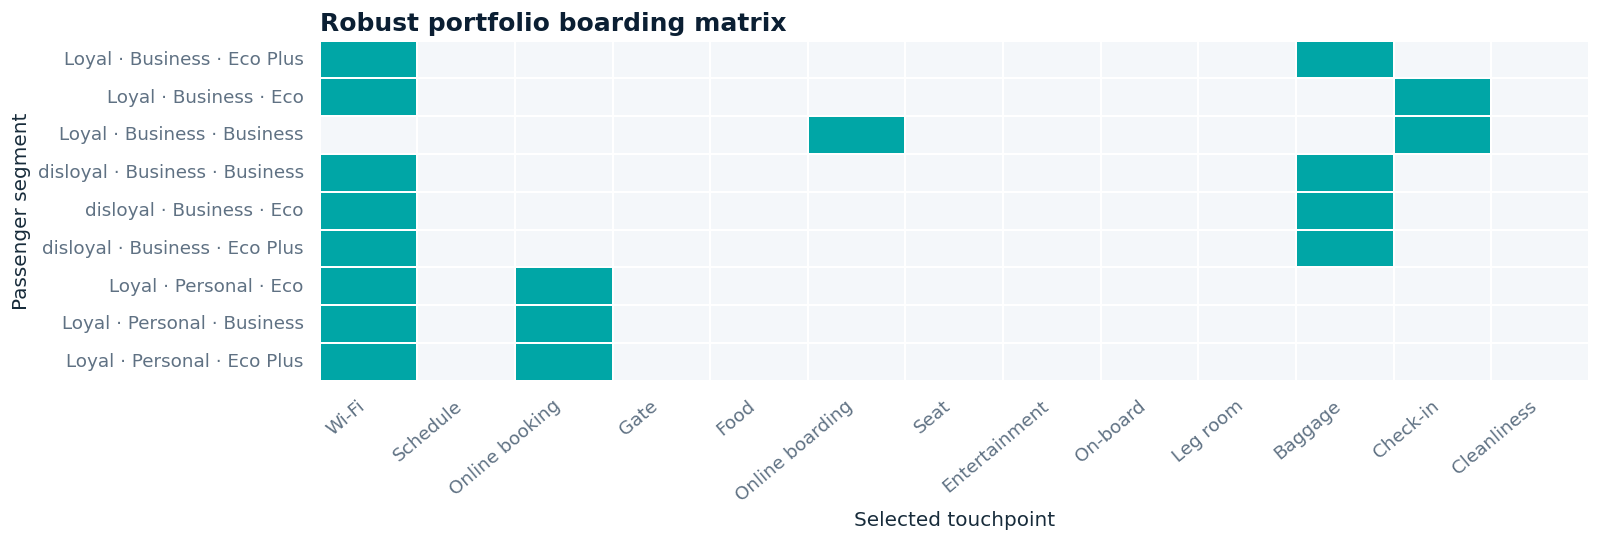

In [ ]:
selection = pd.DataFrame(0, index=segment_robust["segment"], columns=[SERVICE_SHORT[s] for s in SERVICE_COLS])
for row in segment_robust.itertuples():
    for service in row.portfolio:
        selection.loc[row.segment, SERVICE_SHORT[service]] = 1

fig, ax = plt.subplots(figsize=(13.5, max(4.5, 0.52 * len(selection))))
sns.heatmap(selection, cmap=LinearSegmentedColormap.from_list("selected", ["#F4F7FA", TEAL]),
            cbar=False, linewidths=1, linecolor="white", ax=ax)
ax.set_xlabel("Selected touchpoint")
ax.set_ylabel("Passenger segment")
ax.set_title("Robust portfolio boarding matrix", loc="left", fontsize=15)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

**10. Stability audit¶**
For each bootstrap model, we identify its individually optimal feasible portfolio. The selection frequency below shows whether a touchpoint remains attractive when the model is refitted. A low frequency means the recommendation is model-sensitive even if its average uplift is high.

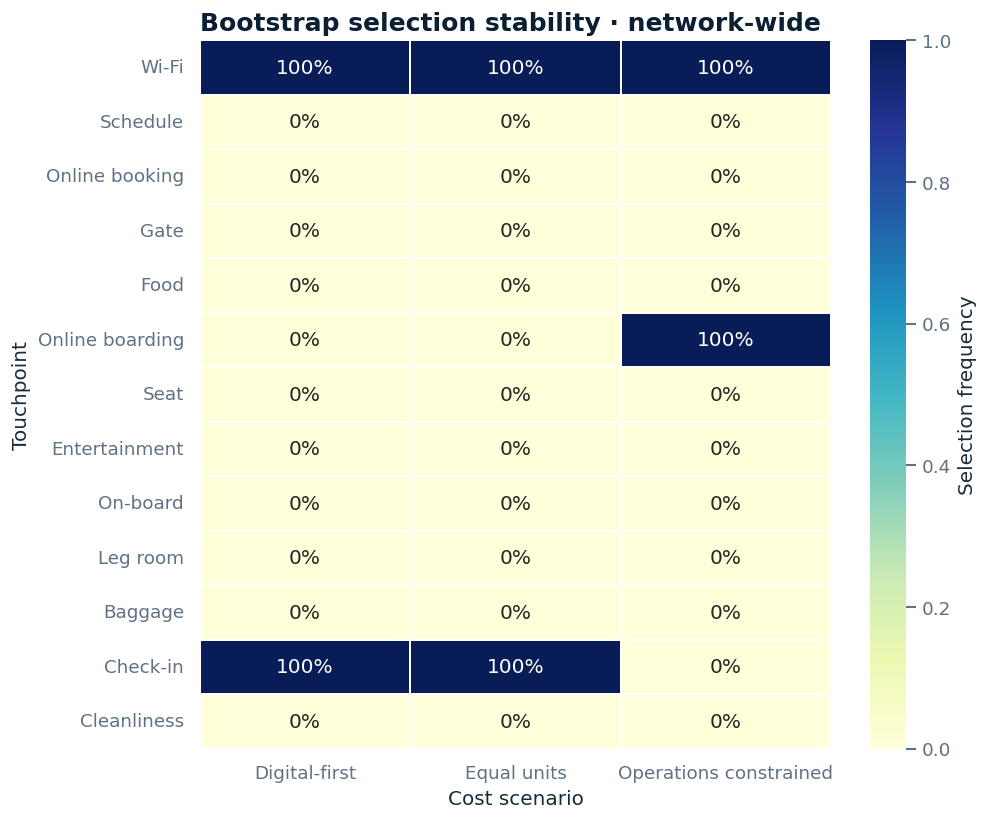

In [ ]:
stability_rows = []
for scenario in COST_SCENARIOS:
    candidates = feasible_portfolios(scenario)
    for segment in SEGMENTS:
        part = design_sim[
            design_sim["segment"].eq(segment) & design_sim["portfolio"].isin(candidates)
        ]
        for model_name, model_part in part.groupby("model"):
            winner = model_part.sort_values("mean_delta", ascending=False).iloc[0]["portfolio"]
            for service in SERVICE_COLS:
                stability_rows.append({
                    "scenario": scenario, "segment": segment, "model": model_name,
                    "service": service, "selected": int(service in winner),
                })
stability = pd.DataFrame(stability_rows)

network_stability = (
    stability[stability["segment"].eq("Network-wide")]
    .groupby(["scenario", "service"], as_index=False)["selected"].mean()
    .pivot(index="service", columns="scenario", values="selected")
    .reindex(SERVICE_COLS).rename(index=SERVICE_SHORT)
)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(network_stability, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=1, linecolor="white", cbar_kws={"label": "Selection frequency"}, ax=ax)
ax.set_xlabel("Cost scenario")
ax.set_ylabel("Touchpoint")
ax.set_title("Bootstrap selection stability · network-wide", loc="left", fontsize=15)
plt.tight_layout()
plt.show()

**11. Equality of improvement effort¶**
For each segment, the planner finds the minimum hypothetical cost whose robust design-set uplift reaches at least five percentage points. The selected plan is then evaluated on the final test set. A large cost range signals unequal model-estimated effort across passenger groups.

In [ ]:
EFFORT_SCENARIO = "Operations constrained"
TARGET_UPLIFT = 0.05
effort_rows = []
for segment in valid_segments:
    part = design_robust[
        design_robust["segment"].eq(segment)
        & design_robust["portfolio"].isin(VALID_PORTFOLIOS)
    ].copy()
    part["cost"] = part["portfolio"].map(lambda p: portfolio_cost(p, EFFORT_SCENARIO))
    qualifying = part[part["uplift_p10"].ge(TARGET_UPLIFT)].sort_values(
        ["cost", "uplift_p10"], ascending=[True, False]
    )
    if qualifying.empty:
        effort_rows.append({"segment": segment, "portfolio": None, "cost": np.nan, "design_p10": np.nan})
        continue
    chosen = qualifying.iloc[0]
    effort_rows.append({
        "segment": segment, "portfolio": chosen["portfolio"],
        "cost": chosen["cost"], "design_p10": chosen["uplift_p10"],
    })

effort = pd.DataFrame(effort_rows)
effort["portfolio_label"] = effort["portfolio"].map(lambda p: portfolio_label(p) if isinstance(p, tuple) else "No feasible plan")
effort = effort.merge(
    test_lookup[["segment", "portfolio", "mean_delta", "helped_5pp", "flip_rate"]],
    on=["segment", "portfolio"], how="left"
).sort_values("cost")

display(effort[["segment", "portfolio_label", "cost", "design_p10", "mean_delta", "helped_5pp"]]
        .style.format({"cost": "{:.1f}", "design_p10": "{:+.2%}",
                       "mean_delta": "{:+.2%}", "helped_5pp": "{:.1%}"})
        .set_caption("Minimum robust effort for a 5pp planning target"))

,segment,portfolio_label,cost,design_p10,mean_delta,helped_5pp
0,Loyal · Business · Business,Online boarding,0.6,+19.44%,+18.74%,38.6%
1,Loyal · Business · Eco,Online boarding,0.6,+16.05%,+13.17%,43.4%
2,Loyal · Business · Eco Plus,Online boarding,0.6,+14.99%,+15.58%,43.5%
3,Loyal · Personal · Business,Wi-Fi,2.4,+15.79%,+17.15%,44.8%
4,Loyal · Personal · Eco,Wi-Fi,2.4,+17.67%,+17.41%,43.5%
5,Loyal · Personal · Eco Plus,Wi-Fi,2.4,+15.19%,+15.10%,40.1%
6,disloyal · Business · Business,Wi-Fi,2.4,+17.47%,+18.96%,49.1%
7,disloyal · Business · Eco,Wi-Fi,2.4,+16.07%,+16.47%,38.7%
8,disloyal · Business · Eco Plus,Wi-Fi,2.4,+23.13%,+16.23%,36.3%


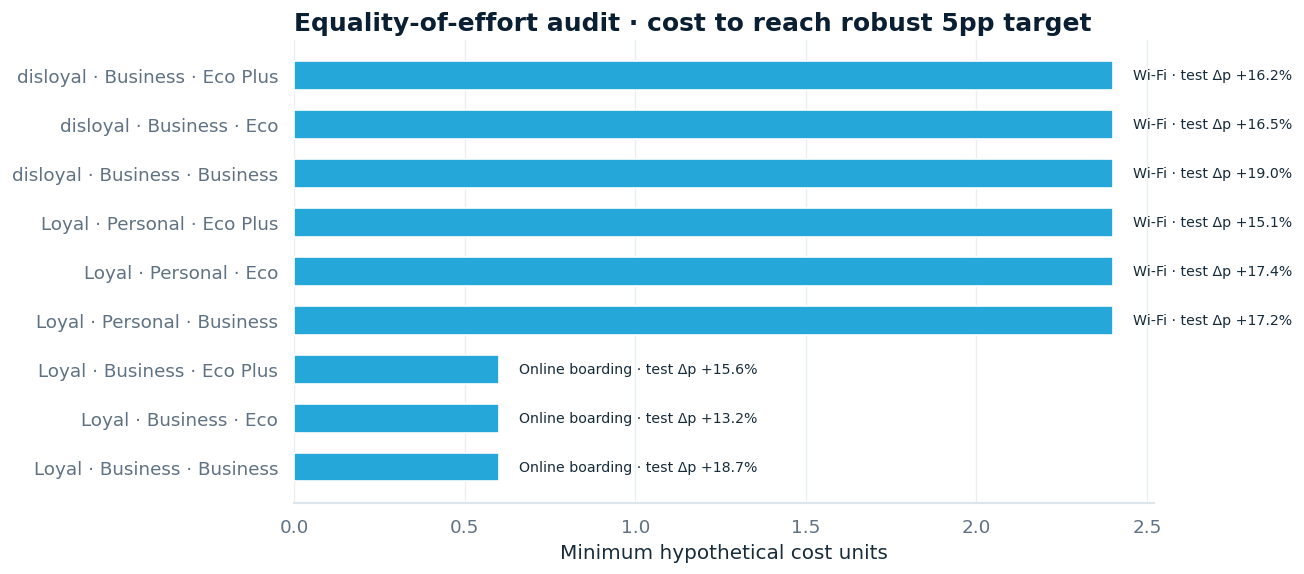

Effort range: 0.6–2.4 cost units
Realized test-uplift range: 13.2%–19.0%


In [ ]:
plot_effort = effort.dropna(subset=["cost"]).sort_values("cost")
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.55 * len(plot_effort))))
ypos = np.arange(len(plot_effort))
ax.barh(ypos, plot_effort["cost"], color=SKY, height=0.58)
for i, row in enumerate(plot_effort.itertuples()):
    ax.text(row.cost + 0.06, i, f"{row.portfolio_label} · test Δp {row.mean_delta:+.1%}", va="center", fontsize=8.5)
ax.set_yticks(ypos, plot_effort["segment"])
ax.set_xlabel("Minimum hypothetical cost units")
ax.set_title("Equality-of-effort audit · cost to reach robust 5pp target", loc="left", fontsize=15)
finish_axis(ax)
plt.tight_layout()
plt.show()

if len(plot_effort):
    print(f"Effort range: {plot_effort['cost'].min():.1f}–{plot_effort['cost'].max():.1f} cost units")
    print(f"Realized test-uplift range: {plot_effort['mean_delta'].min():.1%}–{plot_effort['mean_delta'].max():.1%}")

**12. Automated executive briefing¶**
The text below is calculated from the selected policies and untouched final test. It will update if costs, budgets, model parameters, or data change.

In [ ]:
network_robust = evaluation[
    evaluation["scenario"].eq("Equal units")
    & evaluation["segment"].eq("Network-wide")
    & evaluation["method"].eq("Robust portfolio")
].iloc[0]
network_shap = evaluation[
    evaluation["scenario"].eq("Equal units")
    & evaluation["segment"].eq("Network-wide")
    & evaluation["method"].eq("Highest-SHAP-first")
].iloc[0]
best_method = balanced_eval.iloc[0]

briefing = f"""
### Investment-planning briefing

- The calibrated model reaches **ROC-AUC {model_metrics.loc[1, 'ROC-AUC']:.4f}** and **Brier score {model_metrics.loc[1, 'Brier']:.4f}** on the untouched final test.
- Under equal-unit costs, the robust network-wide plan selects **{network_robust['portfolio_label']}**.
- Its final-test modeled movement is **{network_robust['mean_delta']:+.1%}**, with **{network_robust['helped_5pp']:.1%}** of historically dissatisfied passengers receiving at least a five-point probability increase.
- The predicted-class flip rate is **{network_robust['flip_rate']:.1%}**.
- Highest-SHAP-first selects **{network_shap['portfolio_label']}** and produces **{network_shap['mean_delta']:+.1%}** modeled movement; importance and intervention value are therefore {'not identical' if network_shap['portfolio'] != network_robust['portfolio'] else 'aligned in this scenario'}.
- The strongest final-test method in the equal-unit network-wide comparison is **{best_method['method']}** with **{best_method['portfolio_label']}**.

### Decision rule

Use these portfolios to prioritize **controlled experiments**—for example, targeted operational pilots or randomized service changes. Do not convert modeled probability movement into revenue or guaranteed satisfaction uplift without experimental validation and real implementation costs.
"""
display(Markdown(briefing))



### Investment-planning briefing

- The calibrated model reaches **ROC-AUC 0.9949** and **Brier score 0.0268** on the untouched final test.
- Under equal-unit costs, the robust network-wide plan selects **Wi-Fi + Check-in**.
- Its final-test modeled movement is **+21.5%**, with **48.5%** of historically dissatisfied passengers receiving at least a five-point probability increase.
- The predicted-class flip rate is **19.1%**.
- Highest-SHAP-first selects **Wi-Fi + Online boarding** and produces **+20.5%** modeled movement; importance and intervention value are therefore not identical.
- The strongest final-test method in the equal-unit network-wide comparison is **Robust portfolio** with **Wi-Fi + Check-in**.

### Decision rule

Use these portfolios to prioritize **controlled experiments**—for example, targeted operational pilots or randomized service changes. Do not convert modeled probability movement into revenue or guaranteed satisfaction uplift without experimental validation and real implementation costs.
